# Sentiment Regression — Debugged Gradient Surgery Pipeline

This notebook keeps the **Möbius** architecture (which is your strongest signal) and rebuilds the gradient-surgery training around **correctness and regularization** rather than aggressive optimization.

## Diagnosis of the previous runs

Looking at the three training curves you shared:

| Curve | What it shows | What it means |
|---|---|---|
| `train/loss` | GradVac & PCGrad ≈ 0.08 vs Default ≈ 0.13 at step 17k | Gradient methods drive **training** loss much harder |
| `eval/rounded_mae` | All three converge to ~0.39–0.41 | But they **don't generalize** any better |
| `train/grad_norm` | GradVac & PCGrad ~2–3× higher with huge variance | The "surgery" is injecting noise and bigger updates |

**This is textbook overfitting.** When training loss diverges from eval performance like that, the extra optimization power is being spent memorizing training-set quirks, not learning the task.

## Are the gradient methods salvageable?

**Yes, but only with three changes:**

1. **Fix the implementation bugs** (details below). The previous PCGrad was applied *per-parameter-tensor* instead of over the full flattened gradient vector (a different algorithm than what the paper describes). The previous GradVac vaccinated only English toward German, not symmetrically — and the `p.grad = (g_en + phi * g_de) + g_de` line effectively doubled the DE gradient.

2. **Regularize harder.** With LoRA r=128 + dual heads + 2 backward passes per step, you have more than enough capacity to memorize. The fix isn't dropping the methods — it's making them inhabit a tighter hypothesis space (lower LoRA r, higher dropout, weight decay, gradient clipping, early stopping on rounded MAE).

3. **Treat surgery as opt-in, not default.** PCGrad/GradVac only help when tasks actually conflict. Your `check_interference_*` helpers exist precisely to measure this. Run them first; switch on surgery only if cosine(g_en, g_de) is meaningfully negative on average.

**Bottom line:** Don't throw the methods away — but the cleanest baseline below is **plain Huber + good regularization**. Switch the `TRAINER_KIND` flag to `"pcgrad"` or `"gradvac"` to A/B against it, and only commit to surgery if it actually beats the regularized baseline on **eval rounded MAE**, not training loss.


In [1]:
%pip install -U -q "torchao>=0.16.0" "peft>=0.10.0" "transformers>=4.40.0" datasets accelerate evaluate scikit-learn seaborn
%load_ext autoreload
%autoreload 2

from util import *
from util import save_custom_model
from transformers import DataCollatorWithPadding

import torch
print(f"GPU Active: {torch.cuda.is_available()}")

Note: you may need to restart the kernel to use updated packages.
GPU Active: True


## 1. Config — change this to switch experiments

Everything that matters for the ablation lives in one place. Don't bury hyperparameters in the trainer instantiation 200 lines down — you'll lose track of what you actually ran.

In [2]:
# ============================================================
# EXPERIMENT CONFIG
# ============================================================

# Which trainer to use: "default" | "pcgrad" | "gradvac" | "class"
TRAINER_KIND = "default"

# Model architecture: "mobius" | "circular" | "regressor" | "class"
MODEL_KIND = "regressor"

# LoRA capacity — was 128, lowered to 32 to reduce overfit headroom.
# If eval plateaus, raise; if train/eval gap is big, lower further.
LORA_R = 64              # 32 for large 64 otherwise
LORA_ALPHA = LORA_R      # alpha == r is a common safe default (effective scale = 1.0)
LORA_DROPOUT = 0.05      # keep 0.01

# Optimization
BATCH_SIZE = 64
EVAL_BATCH_SIZE = 512
LEARNING_RATE = 1.5e-4   # keep as is
WEIGHT_DECAY = 0.01      # was effectively 0; now an actual prior against memorization
WARMUP_STEPS = 200
NUM_EPOCHS = 1
GRAD_CLIP = 1.0          # NEW: keep gradient surgery from emitting giant updates
LABEL_SMOOTHING = 0.0    # for regression this stays 0; flag is here for completeness

# Eval / save
EVAL_STEPS = 750         # was 1500 — eval more often so early-stopping bites earlier
SAVE_STEPS = 3000
EARLY_STOPPING_PATIENCE = 4  # in eval_steps units

# Möbius head config
SARCASM_BIAS_INIT = -3.0  # logit prior: sarcasm is rare
HUBER_DELTA = 0.75        # keep 0.75

# GradVac specifically
GRADVAC_BETA = 0.9        # EMA decay for cosine target

## 2. Data loading & preprocessing

Unchanged in spirit, but I added `seed` plumbing and pull out the `lang` mapping into a constant so it's not implicit.

In [3]:
from datasets import load_dataset, Value
from transformers import AutoTokenizer

file_path = 'data/train_lang.csv'
dataset = load_dataset('csv', data_files=file_path, split='train')

# Stratify hope: train_test_split is random here, which is fine since
# both languages are abundant. If you ever filter to one language, drop
# the stratify hint anyway — HF datasets doesn't honor it the same way.
dataset = dataset.train_test_split(test_size=0.1, seed=67) # regressor 42. classifier 41. large 69. test 67
print(f"Train: {len(dataset['train'])}  Test: {len(dataset['test'])}")

model_id = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

LANG_TO_ID = {"eng_Latn": 0, "deu_Latn": 1}  # explicit mapping; anything not eng is treated as "other"

def preprocess(examples):
    tokenized = tokenizer(
        examples["sentence"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    tokenized["label"] = [float(r) for r in examples["label"]]
    # Same 0/1 convention as before, but explicit
    tokenized["lang"] = [LANG_TO_ID.get(l, 1) for l in examples["lang"]]
    return tokenized

tokenized_ds = dataset.map(
    preprocess, batched=True, remove_columns=dataset["train"].column_names
)
tokenized_ds = tokenized_ds.cast_column("label", Value("float32"))
tokenized_ds = tokenized_ds.cast_column("lang", Value("int64"))
tokenized_ds.set_format("torch")

Train: 226800  Test: 25200


## 3. Metrics

Same as before — `rounded MAE` is the submission metric, `raw_mae` is for debugging precision.

In [4]:
import numpy as np
from sklearn.metrics import mean_absolute_error

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Trainer wraps multi-output forward returns in a tuple.
    # Classifier returns {"logits", "probs"} -> logits is (logits_arr, probs_arr).
    # Regressors return {"logits"} only -> logits is a single array.
    if isinstance(logits, tuple):
        logits = logits[0]

    if logits.ndim == 2 and logits.shape[1] == 5:
        # Classifier: argmax over class dimension
        predictions = logits.argmax(axis=-1).astype(float)
    else:
        # Regressor: squeeze and clip to [0,4]
        predictions = np.clip(logits.squeeze(), 0, 4)

    preds_rounded = np.rint(predictions).astype(int)
    return {
        "mae": mean_absolute_error(labels, preds_rounded),
        "raw_mae": mean_absolute_error(labels, predictions),
    }

## 4. Models

Möbius is unchanged (you said it's working). I kept Circular and the plain Regressor too for completeness — but Möbius is the default.

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    XLMRobertaModel, XLMRobertaConfig, XLMRobertaPreTrainedModel,
)


class XLMRobertaSentimentRegressor(nn.Module):
    """Plain regression head with sigmoid squashing to 0-4."""
    def __init__(self, model_id, config, out_dim=1):
        super().__init__()
        self.config = config
        self.roberta = XLMRobertaModel.from_pretrained(model_id)
        hidden_size = config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Linear(hidden_size // 4, 1),
        )

    def forward(self, input_ids, attention_mask, labels=None, lang=None, **kwargs):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]
        logits = self.regressor(pooled)
        prediction = 4 * torch.sigmoid(logits)
        return {"logits": prediction}


class XLMRobertaSentimentClassifier(nn.Module):
    """Classifier head with no ordinal capabilities."""
    def __init__(self, model_id, config, out_dim=1):
        super().__init__()
        self.config = config
        self.roberta = XLMRobertaModel.from_pretrained(model_id)
        hidden_size = config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Linear(hidden_size // 4, 5),
        )

    def forward(self, input_ids, attention_mask, labels=None, lang=None, **kwargs):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled)                  # (B, 5) — raw logits
        probs = torch.softmax(logits, dim=-1)             # (B, 5) — for inspection
        return {"logits": logits, "probs": probs}


class XLMRobertaCircular(XLMRobertaPreTrainedModel):
    """Circular sentiment with a saturated barrier at the 0/4 boundary."""
    def __init__(self, config):
        super().__init__(config)
        self.roberta = XLMRobertaModel(config)
        hidden_size = config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Linear(hidden_size // 4, 2),
        )
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.roberta(input_ids, attention_mask=attention_mask)
        seq = outputs[0][:, 0, :]
        coords = self.regressor(seq)
        pred_vecs = F.normalize(coords, p=2, dim=1)
        theta = torch.atan2(pred_vecs[:, 1], pred_vecs[:, 0])
        theta_pos = (theta + 2 * torch.pi) % (2 * torch.pi)
        scalar = (theta_pos / (2 * torch.pi)) * 4.0

        loss = None
        if labels is not None:
            target_angles = (labels.float() / 4.0) * 2 * torch.pi
            target_vecs = torch.stack(
                [torch.cos(target_angles), torch.sin(target_angles)], dim=1
            )
            base_loss = (1 - (pred_vecs * target_vecs).sum(dim=1)).mean()

            x_coords = pred_vecs[:, 0]
            delta = 0.2
            threshold = torch.cos(torch.tensor(delta, device=x_coords.device))
            strength = 10.0
            diff = torch.clamp(x_coords - threshold, min=0)
            gap_penalty = torch.tanh(strength * diff).mean()
            loss = base_loss + (0.8 * gap_penalty)

        return {"loss": loss, "logits": scalar} if loss is not None else {"logits": scalar}


class XLMRobertaMobius(XLMRobertaPreTrainedModel):
    """Möbius: intensity head P (0-4) + sarcasm gate S (0-1).
    Final = (1-S)*P + S*(4-P). Sarcasm flips the polarity.
    """
    def __init__(self, config):
        super().__init__(config)
        self.roberta = XLMRobertaModel(config)
        hidden_size = config.hidden_size

        self.intensity_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Linear(hidden_size // 4, 1),
        )
        self.sarcasm_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Linear(hidden_size // 4, 1),
        )
        # Prior: sarcasm is rare. sigmoid(-3.0) ~= 0.047
        self.sarcasm_head[-1].bias.data.fill_(SARCASM_BIAS_INIT)
        self.post_init()
        self.loss_fct = nn.HuberLoss(delta=HUBER_DELTA)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.roberta(input_ids, attention_mask=attention_mask)
        seq = outputs[0][:, 0, :]

        intensity = torch.sigmoid(self.intensity_head(seq)) * 4.0
        sarcasm_prob = torch.sigmoid(self.sarcasm_head(seq))
        final = (1 - sarcasm_prob) * intensity + sarcasm_prob * (4.0 - intensity)

        loss = None
        if labels is not None:
            loss = self.loss_fct(final.view(-1), labels.float().view(-1))
        return {"loss": loss, "logits": final}

## 5. Trainers — debugged

This is the heart of the change. Three things were wrong before:

### Bug 1: PCGrad was per-tensor, not over the full gradient

The previous code computed `dot(g_en, g_de)`, `||g_en||²`, `||g_de||²` *for each parameter tensor separately*. That means every layer ran its own conflict-resolution. The PCGrad paper (Yu et al. 2020) defines projection over the *concatenated* gradient vector — a single scalar dot product decides whether to project, and the projection is one operation in the full parameter space. Per-tensor PCGrad is a different algorithm, and it tends to be noisier because small layers can flip the projection sign per-step.

**Fix:** compute one global `dot` and one global `||·||²` per task, then apply the projection coefficient uniformly.

### Bug 2: GradVac was asymmetric and added `g_de` twice

Old line: `p.grad = (g_en + phi * g_de) + g_de` — this is `g_en + (1 + phi) * g_de`. The intended formula was either "corrected EN + uncorrected DE" or fully symmetric vaccination. The paper does symmetric vaccination.

**Fix:** vaccinate both `g_en` toward target cos with `g_de`, and `g_de` toward target cos with `g_en`, then sum.

### Bug 3: Both methods called `model.zero_grad()` between passes

That's correct *if you're going to manually recombine grads*, but it means you're throwing away the autograd graph and doing two full backward passes. That's fine (we want fresh grads), just expensive — and it does double the per-step compute. Worth knowing when comparing to default.

### What I kept
- Symmetric handling for 2 tasks
- `lang` popped from inputs before forward
- The "no rows for one language → fall back to plain step" safety valve

In [6]:
from transformers import Trainer

# ---------- Plain Huber baseline ----------

class HuberTrainer(Trainer):
    """Plain trainer with Huber loss; ignores `lang`."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Drop lang if present — model doesn't use it in plain mode
        inputs = {k: v for k, v in inputs.items() if k != "lang"}
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.HuberLoss(delta=HUBER_DELTA)
        loss = loss_fct(logits.squeeze(), labels.squeeze())
        return (loss, outputs) if return_outputs else loss


# ------------ CE Loss trainer simple -------

class CrossEntropyTrainer(Trainer):
    """Trainer with cross-entropy loss for the 5-class classifier."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        inputs = {k: v for k, v in inputs.items() if k != "lang"}
        labels = inputs.pop("labels")                     # expected shape: (B,), dtype long

        outputs = model(**inputs)
        logits = outputs["logits"]                        # (B, 5)

        loss_fct = nn.CrossEntropyLoss()
        # labels must be class indices (0–4); cast in case they're float
        loss = loss_fct(logits, labels.long())

        return (loss, outputs) if return_outputs else loss


# ---------- helpers used by both surgery trainers ----------

def _flat_dot(grads_a, grads_b):
    """Single scalar dot product across the FULL parameter vector."""
    total = torch.zeros((), device=grads_a[0].device, dtype=grads_a[0].dtype)
    for ga, gb in zip(grads_a, grads_b):
        total = total + (ga * gb).sum()
    return total

def _flat_sq_norm(grads):
    total = torch.zeros((), device=grads[0].device, dtype=grads[0].dtype)
    for g in grads:
        total = total + (g * g).sum()
    return total

def _split_by_lang(inputs):
    langs = inputs.pop("lang")
    en_idx = (langs == 0).nonzero(as_tuple=True)[0]
    de_idx = (langs == 1).nonzero(as_tuple=True)[0]
    return en_idx, de_idx, langs

def _slice_inputs(inputs, idx):
    return {k: v[idx] for k, v in inputs.items()}

def _collect_grads(params):
    return [
        p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p)
        for p in params
    ]


# ---------- PCGrad (fixed: global projection, not per-tensor) ----------

class PCGradHuberTrainer(HuberTrainer):
    def training_step(self, model, inputs, num_items_in_batch=None, **kwargs):
        model.train()
        en_idx, de_idx, _ = _split_by_lang(inputs)

        # Safety valve: monolingual batch → just do a normal step
        if len(en_idx) == 0 or len(de_idx) == 0:
            loss = self.compute_loss(model, inputs)
            self.accelerator.backward(loss)
            return loss.detach()

        inputs_en = _slice_inputs(inputs, en_idx)
        inputs_de = _slice_inputs(inputs, de_idx)
        params = [p for p in model.parameters() if p.requires_grad]

        # Pass A — English
        model.zero_grad()
        loss_en = self.compute_loss(model, inputs_en)
        self.accelerator.backward(loss_en)
        grads_en = _collect_grads(params)

        # Pass B — German
        model.zero_grad()
        loss_de = self.compute_loss(model, inputs_de)
        self.accelerator.backward(loss_de)
        grads_de = _collect_grads(params)

        # Global PCGrad surgery — ONE scalar dot, ONE pair of squared norms
        model.zero_grad()
        with torch.no_grad():
            dot = _flat_dot(grads_en, grads_de)
            if dot.item() < 0:
                norm_en_sq = _flat_sq_norm(grads_en) + 1e-8
                norm_de_sq = _flat_sq_norm(grads_de) + 1e-8
                coef_en_off_de = dot / norm_de_sq  # remove this much of g_de from g_en
                coef_de_off_en = dot / norm_en_sq

                for p, g_en, g_de in zip(params, grads_en, grads_de):
                    g_en_proj = g_en - coef_en_off_de * g_de
                    g_de_proj = g_de - coef_de_off_en * g_en
                    p.grad = g_en_proj + g_de_proj
            else:
                # No conflict → standard sum (== average up to scaling)
                for p, g_en, g_de in zip(params, grads_en, grads_de):
                    p.grad = g_en + g_de

        return (loss_en + loss_de).detach() / 2.0


# ---------- GradVac (fixed: symmetric vaccination, single g_de) ----------

class GradVacTrainer(HuberTrainer):
    """Wang et al. (2021) gradient vaccine. Maintains an EMA of inter-task
    cosine similarity and rotates each gradient toward that target when
    the current cosine drops below it."""
    def __init__(self, *args, beta=GRADVAC_BETA, **kwargs):
        super().__init__(*args, **kwargs)
        self.beta = beta
        self.rho_12 = 0.0  # EMA target cosine

    def training_step(self, model, inputs, num_items_in_batch=None, **kwargs):
        model.train()
        en_idx, de_idx, _ = _split_by_lang(inputs)

        if len(en_idx) == 0 or len(de_idx) == 0:
            loss = self.compute_loss(model, inputs)
            self.accelerator.backward(loss)
            return loss.detach()

        inputs_en = _slice_inputs(inputs, en_idx)
        inputs_de = _slice_inputs(inputs, de_idx)
        params = [p for p in model.parameters() if p.requires_grad]

        model.zero_grad()
        loss_en = self.compute_loss(model, inputs_en)
        self.accelerator.backward(loss_en)
        grads_en = _collect_grads(params)

        model.zero_grad()
        loss_de = self.compute_loss(model, inputs_de)
        self.accelerator.backward(loss_de)
        grads_de = _collect_grads(params)

        model.zero_grad()
        with torch.no_grad():
            # Global flat vectors for cos computation
            norm_en = torch.sqrt(_flat_sq_norm(grads_en) + 1e-12)
            norm_de = torch.sqrt(_flat_sq_norm(grads_de) + 1e-12)
            dot = _flat_dot(grads_en, grads_de)
            cos_theta = (dot / (norm_en * norm_de + 1e-8)).clamp(-1 + 1e-6, 1 - 1e-6)

            # Update EMA target
            self.rho_12 = self.beta * self.rho_12 + (1 - self.beta) * cos_theta.item()

            if cos_theta.item() < self.rho_12:
                # Both directions get rotated toward each other
                rho_t = torch.tensor(self.rho_12, device=cos_theta.device, dtype=cos_theta.dtype)
                sin_theta = torch.sqrt(1 - cos_theta ** 2 + 1e-8)
                sin_target = torch.sqrt(1 - rho_t ** 2 + 1e-8)

                phi_en = (norm_en * (rho_t * sin_theta - cos_theta * sin_target)) / (norm_de * sin_target + 1e-8)
                phi_de = (norm_de * (rho_t * sin_theta - cos_theta * sin_target)) / (norm_en * sin_target + 1e-8)

                for p, g_en, g_de in zip(params, grads_en, grads_de):
                    g_en_new = g_en + phi_en * g_de
                    g_de_new = g_de + phi_de * g_en
                    p.grad = g_en_new + g_de_new
            else:
                for p, g_en, g_de in zip(params, grads_en, grads_de):
                    p.grad = g_en + g_de

        return (loss_en + loss_de).detach() / 2.0

## 6. Build the model

LoRA `r` dropped from **128 → 32** and dropout bumped from **0.01 → 0.1**. With the surgery methods this is non-negotiable — they were memorizing because they had ~4× more LoRA capacity than they needed.

In [7]:
from peft import LoraConfig, get_peft_model

if MODEL_KIND == "mobius":
    model = XLMRobertaMobius.from_pretrained(model_id)
    modules_to_save = ["intensity_head", "sarcasm_head"]
elif MODEL_KIND == "class":
    model = XLMRobertaSentimentClassifier(
        model_id, XLMRobertaConfig.from_pretrained(model_id)
    )
    modules_to_save = ["classifier"]
elif MODEL_KIND == "circular":
    model = XLMRobertaCircular.from_pretrained(model_id)
    modules_to_save = ["regressor"]
elif MODEL_KIND == "regressor":
    model = XLMRobertaSentimentRegressor(
        model_id, XLMRobertaConfig.from_pretrained(model_id)
    )
    modules_to_save = ["regressor"]
else:
    raise ValueError(f"Unknown MODEL_KIND: {MODEL_KIND}")

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=[
        "query", "key", "value",
        "intermediate.dense",
        "output.dense",
    ],
    modules_to_save=modules_to_save,
    lora_dropout=LORA_DROPOUT,
    task_type="SEQ_CLS",
)
model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"trainable: {trainable:,} || total: {total:,} || trainable%: {100 * trainable / total:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable: 10,986,241 || total: 289,399,298 || trainable%: 3.7962


## 7. Trainer setup

Key adds vs the previous notebook:

- `weight_decay=0.01` (was 0)
- `max_grad_norm=1.0` clipping (was unset — gradient surgery can spit out big steps)
- `metric_for_best_model="mae"` + `load_best_model_at_end=True` + `EarlyStoppingCallback`
- `eval_steps=500` instead of 1500 — early stopping needs more signal
- `report_to="none"` by default; flip to `"wandb"` when you actually want to log

In [8]:
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir=f"./sentiment_results_{TRAINER_KIND}_{MODEL_KIND}_large",
    per_device_train_batch_size=BATCH_SIZE, # 32
    per_device_eval_batch_size=32,#EVAL_BATCH_SIZE, # 32
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type="cosine",
    warmup_steps=WARMUP_STEPS,
    num_train_epochs=NUM_EPOCHS,
    max_grad_norm=GRAD_CLIP,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="mae",
    greater_is_better=False,
    fp16=True,
    logging_steps=10,
    remove_unused_columns=False,
    report_to="none",
)

trainer_cls = {
    "default": HuberTrainer,
    "class": CrossEntropyTrainer,
    "pcgrad": PCGradHuberTrainer,
    "gradvac": GradVacTrainer,
}[TRAINER_KIND]

trainer = trainer_cls(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

print(f"Trainer: {trainer_cls.__name__}")
print(f"Model:   {MODEL_KIND}")
print(f"LoRA:    r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")

Trainer: HuberTrainer
Model:   regressor
LoRA:    r=64, alpha=64, dropout=0.05


## 8. (Recommended) Check whether you actually need gradient surgery

Run this *before* training with PCGrad/GradVac. If the average inter-language gradient cosine is comfortably positive, surgery has nothing to fix — and the surgery overhead is just adding variance.

The `check_interference_*` helpers in `util.py` are designed for exactly this. If average cos > 0 across layers, default trainer is the right call.

In [9]:
# Uncomment to measure gradient interference between EN/DE batches
# before deciding which trainer to use.

# check_interference_balanced(model, dataset, tokenizer, num_batches=10, batch_size=16)

## 9. Train

In [10]:
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss,Mae,Raw Mae
750,0.199064,0.188707,0.437738,0.506647
1500,0.200409,0.174274,0.401071,0.463040
2250,0.167743,0.174419,0.401905,0.453697
3000,0.159184,0.161799,0.381349,0.438709
3750,0.173929,0.161189,0.379802,0.442452
4500,0.179903,0.155472,0.370357,0.432188
5250,0.151808,0.156907,0.372024,0.428857
6000,0.129076,0.154429,0.365516,0.425591
6750,0.130282,0.153376,0.365556,0.426190
7088,0.160211,0.153223,0.364921,0.426624


TrainOutput(global_step=7088, training_loss=0.18898965357792297, metrics={'train_runtime': 3365.1857, 'train_samples_per_second': 67.396, 'train_steps_per_second': 2.106, 'total_flos': 0.0, 'train_loss': 0.18898965357792297, 'epoch': 1.0})

In [11]:
model.save_pretrained(f"./sentiment_results_model_{TRAINER_KIND}_{MODEL_KIND}_large")

## Ensemble

Enter a different seed! 

In [9]:
from peft import PeftModel

def load_plain_model(model_cls, directory, model_id="xlm-roberta-base", device="cuda"):
    config = XLMRobertaConfig.from_pretrained(model_id)
    model = model_cls(model_id=model_id, config=config)

def load_lora_model(model_cls, adapter_dir, model_id="xlm-roberta-base", device="cpu"):
    # 1. Build the base model (same class + init you used during training)
    config = XLMRobertaConfig.from_pretrained(model_id)
    base_model = model_cls(model_id=model_id, config=config)

    # 2. Wrap it with the trained LoRA adapter
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.to(device).eval()
    return model

device = "cuda"

# big guys only
reg_model = load_lora_model(
    XLMRobertaSentimentRegressor,
    "./sentiment_results_model_default_regressor_large", # changed to large for now 
    model_id = "xlm-roberta-large",
    device=device,
)

# base only 
cls_model = load_lora_model(
    XLMRobertaSentimentClassifier,
    "./sentiment_results_model_class_class",
    device=device,
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error
from tqdm.auto import tqdm


@torch.no_grad()
def collect_predictions(model, dataloader, device):
    """Run model over a dataloader once, return raw logits + labels as numpy."""
    model.eval()
    all_logits, all_labels = [], []
    for batch in tqdm(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]
        out = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = out["logits"].detach().cpu().numpy()
        all_logits.append(logits)
        all_labels.append(labels.detach().cpu().numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_labels, axis=0)


# ---- Run once to cache raw outputs ----
reg_logits, labels = collect_predictions(reg_model, trainer.get_eval_dataloader(), device)
cls_logits, _      = collect_predictions(cls_model, trainer.get_eval_dataloader(), device)

reg_scores = np.clip(reg_logits.squeeze(), 0, 4)            # (N,) continuous in [0,4]
cls_probs  = torch.softmax(torch.tensor(cls_logits), -1).numpy()  # (N, 5)
cls_expected = cls_probs @ np.arange(5)                      # (N,) expected class
cls_argmax   = cls_logits.argmax(axis=-1).astype(float)      # (N,) hard class

  0%|          | 0/788 [00:00<?, ?it/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


  0%|          | 0/788 [00:00<?, ?it/s]

In [11]:
# ---- Option 1: blend on the continuous scale ----
# Regression score (continuous) + classifier's expected value (sum_k k * p_k).
# This keeps gradient-like information from both models before rounding.
def ensemble_continuous(w, reg_scores, cls_expected):
    blended = w * reg_scores + (1 - w) * cls_expected
    return np.rint(np.clip(blended, 0, 4)).astype(int)


# ---- Option 2: blend rounded predictions ----
# Both models produce integer 0-4, then weighted-average the integers and round.
# Cruder but sometimes more robust if one model's continuous output is miscalibrated.
def ensemble_rounded(w, reg_scores, cls_argmax):
    reg_rounded = np.rint(reg_scores)
    blended = w * reg_rounded + (1 - w) * cls_argmax
    return np.rint(np.clip(blended, 0, 4)).astype(int)


# ---- Weight search ----
def find_best_weight(predict_fn, labels, *args, grid=np.linspace(0, 1, 101)):
    results = []
    for w in grid:
        preds = predict_fn(w, *args)
        mae = mean_absolute_error(labels, preds)
        results.append((w, mae))
    results = np.array(results)
    best_idx = results[:, 1].argmin()
    return results[best_idx, 0], results[best_idx, 1], results


w1, mae1, sweep1 = find_best_weight(ensemble_continuous, labels, reg_scores, cls_expected)
w2, mae2, sweep2 = find_best_weight(ensemble_rounded,    labels, reg_scores, cls_argmax)

print(f"Option 1 (continuous blend): w_reg={w1:.2f}, MAE={mae1:.4f}")
print(f"Option 2 (rounded blend):    w_reg={w2:.2f}, MAE={mae2:.4f}")

# Baselines for sanity
print(f"  Reg-only MAE:  {mean_absolute_error(labels, np.rint(reg_scores).astype(int)):.4f}")
print(f"  Cls-only MAE:  {mean_absolute_error(labels, cls_argmax.astype(int)):.4f}")

Option 1 (continuous blend): w_reg=0.91, MAE=0.3580
Option 2 (rounded blend):    w_reg=0.84, MAE=0.3599
  Reg-only MAE:  0.3600
  Cls-only MAE:  0.3877


## Ensemble-Based Experiments

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix


def get_rounded_preds(logits):
    """Convert raw model outputs to integer 0-4 predictions."""
    logits = np.asarray(logits)
    if logits.ndim == 2 and logits.shape[1] == 5:
        return logits.argmax(axis=-1).astype(int)
    return np.clip(np.rint(logits.squeeze()), 0, 4).astype(int)


# ---- Experiment 1: Error correlation matrix ----
def error_correlation_matrix(model_outputs, labels):
    """
    model_outputs: dict[str, np.ndarray] mapping model name -> raw logits
    labels:        np.ndarray of true integer labels
    Returns a DataFrame of pairwise Pearson correlations between signed errors.
    """
    errors = {
        name: get_rounded_preds(logits) - labels
        for name, logits in model_outputs.items()
    }
    err_df = pd.DataFrame(errors)
    corr = err_df.corr()
    return corr


model_outputs = {
    "regressor":  reg_logits,
    "classifier": cls_logits,
    # add more here as you train them, e.g. "mobius": mobius_logits
}

corr_df = error_correlation_matrix(model_outputs, labels)
print("Error correlation matrix:")
print(corr_df.round(3))
print()
print("Interpretation:")
print("  > 0.90 : models are near-clones, ensembling won't help much")
print("  0.70-0.90 : moderate diversity, ensembling gives small gains")
print("  < 0.70 : good diversity, ensembling should help meaningfully")

Error correlation matrix:
            regressor  classifier
regressor       1.000       0.826
classifier      0.826       1.000

Interpretation:
  > 0.90 : models are near-clones, ensembling won't help much
  0.70-0.90 : moderate diversity, ensembling gives small gains
  < 0.70 : good diversity, ensembling should help meaningfully


In [14]:
# ---- Experiment 2: Per-class confusion ----
def per_class_breakdown(preds, labels, name="model"):
    """Print confusion matrix + per-class MAE + flag polarity flips (|err| >= 3)."""
    cm = confusion_matrix(labels, preds, labels=[0, 1, 2, 3, 4])
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{i}" for i in range(5)],
        columns=[f"pred_{i}" for i in range(5)],
    )

    abs_err = np.abs(preds - labels)
    per_class_mae = {
        i: abs_err[labels == i].mean() if (labels == i).any() else np.nan
        for i in range(5)
    }

    # Adjacent confusions (|err|=1) vs far confusions (|err|>=2) vs polarity flips (|err|>=3)
    adjacent = (abs_err == 1).sum()
    far      = (abs_err >= 2).sum()
    flips    = (abs_err >= 3).sum()
    total    = len(labels)

    print(f"=== {name} ===")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm_df)
    print(f"\nPer-class MAE: { {k: round(v, 3) for k, v in per_class_mae.items()} }")
    print(f"Adjacent errors (|err|=1):     {adjacent} ({100*adjacent/total:.1f}%)")
    print(f"Far errors      (|err|>=2):    {far} ({100*far/total:.1f}%)")
    print(f"Polarity flips  (|err|>=3):    {flips} ({100*flips/total:.1f}%)")
    print()


# Run breakdown for each individual model and for your best ensemble so far
reg_preds = get_rounded_preds(reg_logits)
cls_preds = get_rounded_preds(cls_logits)

# Best ensemble from your earlier sweep — adjust w_reg if needed
w_reg = 0.91
ensemble_continuous = w_reg * reg_scores + (1 - w_reg) * cls_expected
ensemble_preds = np.rint(np.clip(ensemble_continuous, 0, 4)).astype(int)

per_class_breakdown(reg_preds, labels, name="Regressor")
per_class_breakdown(cls_preds, labels, name="Classifier")
per_class_breakdown(ensemble_preds, labels, name="Ensemble (continuous, w=0.67)")

=== Regressor ===
Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1  pred_2  pred_3  pred_4
true_0    3596    1259     119       9      10
true_1     823    3177     935      60      10
true_2     167    1329    2809     684      86
true_3      21     111     735    3018    1191
true_4       2      18      60     687    4284

Per-class MAE: {0: np.float64(0.313), 1: np.float64(0.381), 2: np.float64(0.496), 3: np.float64(0.436), 4: np.float64(0.172)}
Adjacent errors (|err|=1):     7643 (30.3%)
Far errors      (|err|>=2):    673 (2.7%)
Polarity flips  (|err|>=3):    70 (0.3%)

=== Classifier ===
Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1  pred_2  pred_3  pred_4
true_0    3662    1171     126      16      18
true_1     967    3018     932      67      21
true_2     287    1352    2692     647      97
true_3      57     108     837    2907    1167
true_4       8      20      62     757    4204

Per-class MAE: {0: np.float64(0.309), 1: np.float64(0.419), 2

## 10. Error analysis

Unchanged — but now `load_best_model_at_end=True` means `model` in scope is the best-eval-MAE checkpoint, not the last one. That alone usually wins a few points on Kaggle.

In [16]:
df_errors = get_error_dataframe(model, trainer.get_eval_dataloader(), tokenizer)

Calculating Errors:   0%|          | 0/50 [00:00<?, ?it/s]

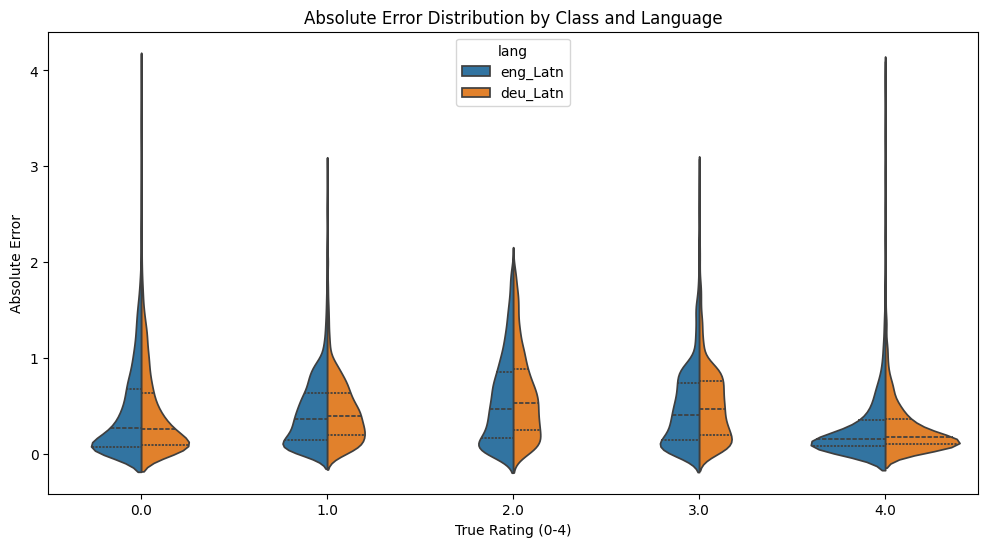


=== ABSOLUTE WORST PREDICTIONS ===


,true_label,predicted,error,lang,text
13359,0.0,3.976562,3.976562,eng_Latn,Five Stars Rusted after 3 week use. The syrup ...
14019,0.0,3.972656,3.972656,deu_Latn,Philips hat es einfach drauf Philips hat es ma...
5565,4.0,0.042267,3.957733,eng_Latn,"Don't waste your money Simply put , don't wast..."
4441,4.0,0.043427,3.956573,eng_Latn,"Wrong, Used Item Sent I received the wrong, us..."
24755,4.0,0.044647,3.955353,eng_Latn,Garbage Band does not close. Watch is useless....
7907,4.0,0.048950,3.951050,eng_Latn,GET THESE. Do not replace your Bose headphones...
25031,4.0,0.062866,3.937134,deu_Latn,Keine Angabe Ist bei mir leider nie angekommen.
11691,0.0,3.914062,3.914062,eng_Latn,So easy to use The best invention since colore...
11909,4.0,0.107056,3.892944,eng_Latn,This egg holder product is not useful! This pr...
15024,0.0,3.878906,3.878906,deu_Latn,Perfekt für Saft Jedes Wochenende jetzt frisch...


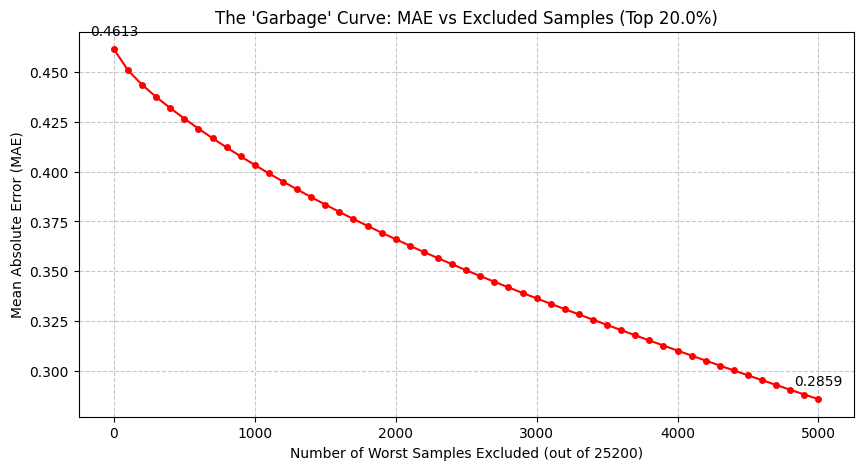

In [17]:
from util import calculate_pruned_mae, plot_pruning_impact

plot_error_distribution(df_errors)

print("\n=== ABSOLUTE WORST PREDICTIONS ===")
worst_overall = get_worst_offenders(df_errors, top_n=20)
display(worst_overall[["true_label", "predicted", "error", "lang", "text"]])

plot_pruning_impact(df_errors, max_exclude_pct=0.2)

In [ ]:
# Inter-task gradient interference, post-training
# (Useful to see if your final model still has conflicting gradients,
#  which would justify keeping surgery on for the next run.)

# check_interference_sampled(trainer, model)

## 11. Pruning + retrain loop

Unchanged from before — your existing pruning helper drops the worst N from the training set and writes a new CSV you can point `file_path` at on the next pass.

In [ ]:
original_df = load_dataset('csv', data_files=file_path, split='train')
prune_and_save_dataset(original_df, df_errors, 7500, output_path="train_lang_pruned.csv")

## 12. Inference & submission

In [18]:
model = reg_model

In [20]:
import pandas as pd
import numpy as np
from datasets import Dataset
from tqdm.auto import tqdm

df_test = pd.read_csv("data/test.csv")
test_ds = Dataset.from_pandas(df_test)

def preprocess_test(examples):
    return tokenizer(
        examples["sentence"], truncation=True, padding="max_length", max_length=128
    )

tokenized_test = test_ds.map(preprocess_test, batched=True)
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask"])

model.eval()
raw_outputs = []
test_loader = torch.utils.data.DataLoader(tokenized_test, batch_size=32)#1024)

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        inputs = {k: v.to("cuda:0") for k, v in batch.items() if k in ["input_ids", "attention_mask"]}
        out = model(**inputs)
        raw_outputs.extend(out["logits"].squeeze().cpu().numpy())

final_preds = np.clip(raw_outputs, 0, 4)
final_preds = np.rint(final_preds).astype(int)

df_test["label"] = final_preds
df_test[["id", "label"]].to_csv("submission_large.csv", index=False)
print("Saved submission.csv")

Map:   0%|          | 0/168000 [00:00<?, ? examples/s]

Predicting:   0%|          | 0/5250 [00:00<?, ?it/s]

Saved submission.csv


## Suggested ablation order

To actually answer "are the gradient methods worth keeping":

1. **Run `TRAINER_KIND = "default"`** with the new regularization (LoRA r=32, dropout=0.1, weight decay, early stop). This is your honest baseline. Note best eval `mae`.
2. **Optional: run `check_interference_balanced`** on the trained baseline. If avg cos(g_en, g_de) is already > 0 across layers, stop here — surgery won't help.
3. **Run `TRAINER_KIND = "pcgrad"`** with identical hyperparameters. Compare best eval `mae`, not training loss.
4. **Run `TRAINER_KIND = "gradvac"`** likewise.

If surgery doesn't beat default by at least ~0.005 rounded MAE *consistently across seeds*, you have your answer: the methods aren't earning their compute. Drop them, keep Möbius + the new regularization, and put your time into data pruning + augmentation instead.